In [20]:
import sys, os
sys.path.append('../')
os.environ["JAX_PLATFORMS"] = "cpu"

import jax
jax.config.update("jax_enable_x64", True)
import numpy as np
import matplotlib.pyplot as plt

from corr_coeff_functions import build_corr_coeff_2D_ties, build_rankdata_2D_ties
from geometry import L2_distance, pairwise_similarities

master_key = jax.random.PRNGKey(12345)
key_x, key_eps = jax.random.split(master_key, 2)

Ns = 500
D = 1

X = jax.random.uniform(key_x, (Ns, D), minval=-2.0, maxval=2.0)
noise_variance = 0.1
noise_scale = np.sqrt(noise_variance)
epsilon = jax.random.normal(key_eps, X.shape)
Y = X ** 2 + noise_scale * epsilon

rankdata_2D_ties = build_rankdata_2D_ties()
xi_point_fn = build_corr_coeff_2D_ties(average=False)


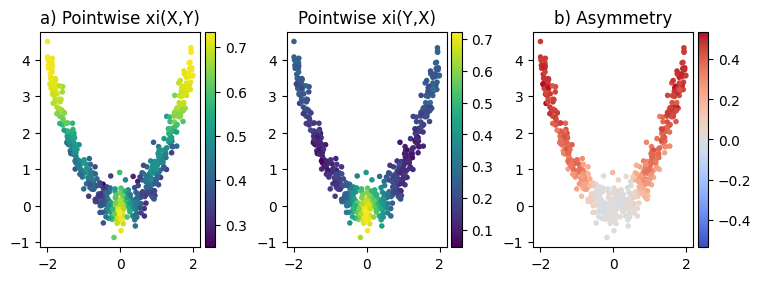

In [21]:
sim_X_all_ref = pairwise_similarities(L2_distance, X, X)
sim_Y_all_ref = pairwise_similarities(L2_distance, Y, Y)

key_xi_all_x, key_xi_all_y = jax.random.split(jax.random.PRNGKey(54321))
ranks_x_all_ref = rankdata_2D_ties(sim_X_all_ref, key_xi_all_x)
ranks_y_all_ref = rankdata_2D_ties(sim_Y_all_ref, key_xi_all_y)

xi_xy_all_ref, xi_yx_all_ref = xi_point_fn((ranks_x_all_ref, ranks_y_all_ref))
xi_xy_all_ref = np.array(xi_xy_all_ref)
xi_yx_all_ref = np.array(xi_yx_all_ref)
xi_asym_ref = xi_xy_all_ref - xi_yx_all_ref

fig, axes = plt.subplots(1, 3, figsize=(9.2, 2.8), gridspec_kw={'wspace': 0.12})

sc0 = axes[0].scatter(
    np.array(X[:, 0]),
    np.array(Y[:, 0]),
    c=xi_xy_all_ref,
    cmap='viridis',
    s=16,
    edgecolors='none',
)
plt.colorbar(sc0, ax=axes[0], pad=0.02)
axes[0].set_title('a) Pointwise xi(X,Y)')
axes[0].set_aspect('equal', adjustable='box')

sc_mid = axes[1].scatter(
    np.array(X[:, 0]),
    np.array(Y[:, 0]),
    c=xi_yx_all_ref,
    cmap='viridis',
    s=16,
    edgecolors='none',
)
plt.colorbar(sc_mid, ax=axes[1], pad=0.02)
axes[1].set_title('Pointwise xi(Y,X)')
axes[1].set_aspect('equal', adjustable='box')

absmax = np.max(np.abs(xi_asym_ref))
sc1 = axes[2].scatter(
    np.array(X[:, 0]),
    np.array(Y[:, 0]),
    c=xi_asym_ref,
    cmap='coolwarm',
    vmin=-absmax,
    vmax=absmax,
    s=16,
    edgecolors='none',
)
plt.colorbar(sc1, ax=axes[2], pad=0.02)
axes[2].set_title('b) Asymmetry')
axes[2].set_aspect('equal', adjustable='box')

plt.show()
